In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/digital_burnout_productivity_dataset_5M (1).csv")

In [3]:
df.head()

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,...,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,...,3,4,8.0,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,...,7,6,5.0,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,...,9,6,8.0,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,...,10,5,6.0,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,...,1,1,4.0,7,9,7,Focused,64,89,High


In [4]:
df.shape

(5000000, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 34 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake          int64  
 20  physical_activity        float64
 21  stress_l

🌈 Dataset Features Overview

📱 Digital Behavior & Screen Usage


⏱️ Screen time tracking

🌐 App & device usage patterns

🔄 Frequency of checking devices

🌍 Social Media Activity


📲 Platform engagement levels

⚠️ Doomscrolling behavior

⏳ Time spent on feeds & content consumption


🎯 Focus & Deep Work Habits


🧠 Focus session duration

🚫 Distraction frequency

🔕 Deep work consistency

✅ Productivity & Task Performance


📋 Task completion rates

⚡ Work efficiency metrics

🎯 Concentration levels

💤 Health & Wellbeing Indicators

😴 Sleep quality & duration

🏃 Physical activity levels

😰 Stress indicators


🏠 Workplace Environment


🧑‍💻 Remote vs in-office behavior

🔇 Work interruptions

🪑 Work setup & environment stability


🧠 Psychological Factors


💪 Motivation levels

😵 Emotional exhaustion

🧩 Mental fatigue


🎯 Target Variables


🔥 burnout_risk → Predicts likelihood of burnout

📊 productivity_score → Continuous productivity measurement

🏷️ productivity_category → Classification label (e.g., Low / Medium / High)


🤖 Machine Learning Use

✨ This dataset supports:

📈 Regression → Predict productivity & burnout scores

🏷️ Classification → Categorize productivity levels

🧠 Behavioral analysis → Understand factors impacting performance

In [6]:
df.describe()

,user_id,age,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,...,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,burnout_risk,productivity_score
count,5.000000e+06,5.000000e+06,5.000000e+06,4.900000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,...,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,4.900000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,2.500000e+06,3.849935e+01,8.001010e+00,3.517651e+00,1.834645e+00,1.294981e+02,2.094380e+02,1.570431e+02,6.499932e-01,4.500512e+00,...,5.498445e+00,2.529647e+00,5.500410e+00,3.000608e+00,5.499446e+00,5.499560e+00,5.502012e+00,5.500900e+00,4.858374e+01,7.144397e+01
std,1.443376e+06,1.212046e+01,2.494805e+00,1.759434e+00,1.132208e+00,6.928145e+01,1.096646e+02,8.228162e+01,4.769718e-01,2.872723e+00,...,2.871775e+00,1.437845e+00,2.873046e+00,1.999887e+00,2.871916e+00,2.872018e+00,2.871822e+00,2.872481e+00,2.207203e+01,2.149899e+01
min,1.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01,2.000000e+01,1.500000e+01,0.000000e+00,0.000000e+00,...,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.250001e+06,2.800000e+01,6.300000e+00,2.300000e+00,1.000000e+00,6.900000e+01,1.140000e+02,8.600000e+01,0.000000e+00,2.000000e+00,...,3.000000e+00,1.500000e+00,3.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.300000e+01,5.600000e+01
50%,2.500000e+06,3.800000e+01,8.000000e+00,3.500000e+00,1.800000e+00,1.290000e+02,2.090000e+02,1.570000e+02,1.000000e+00,5.000000e+00,...,5.000000e+00,2.500000e+00,6.000000e+00,3.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00,6.000000e+00,4.800000e+01,7.300000e+01
75%,3.750000e+06,4.900000e+01,9.700000e+00,4.700000e+00,2.600000e+00,1.900000e+02,3.040000e+02,2.280000e+02,1.000000e+00,7.000000e+00,...,8.000000e+00,3.500000e+00,8.000000e+00,5.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,6.400000e+01,9.000000e+01
max,5.000000e+06,5.900000e+01,1.800000e+01,1.200000e+01,7.900000e+00,2.490000e+02,3.990000e+02,2.990000e+02,1.000000e+00,9.000000e+00,...,1.000000e+01,1.000000e+01,1.000000e+01,6.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+02,1.000000e+02


In [7]:
((df.isnull().sum()/df.shape[0])*100).round(2)

,0
user_id,0.0
age,0.0
occupation,0.0
work_mode,0.0
device_usage_type,0.0
daily_screen_time,0.0
social_media_hours,2.0
doomscrolling_duration,0.0
app_switch_frequency,0.0
notification_count,0.0


In [8]:
percent_missing = ((df.isnull().sum()/df.shape[0])*100).round(2)

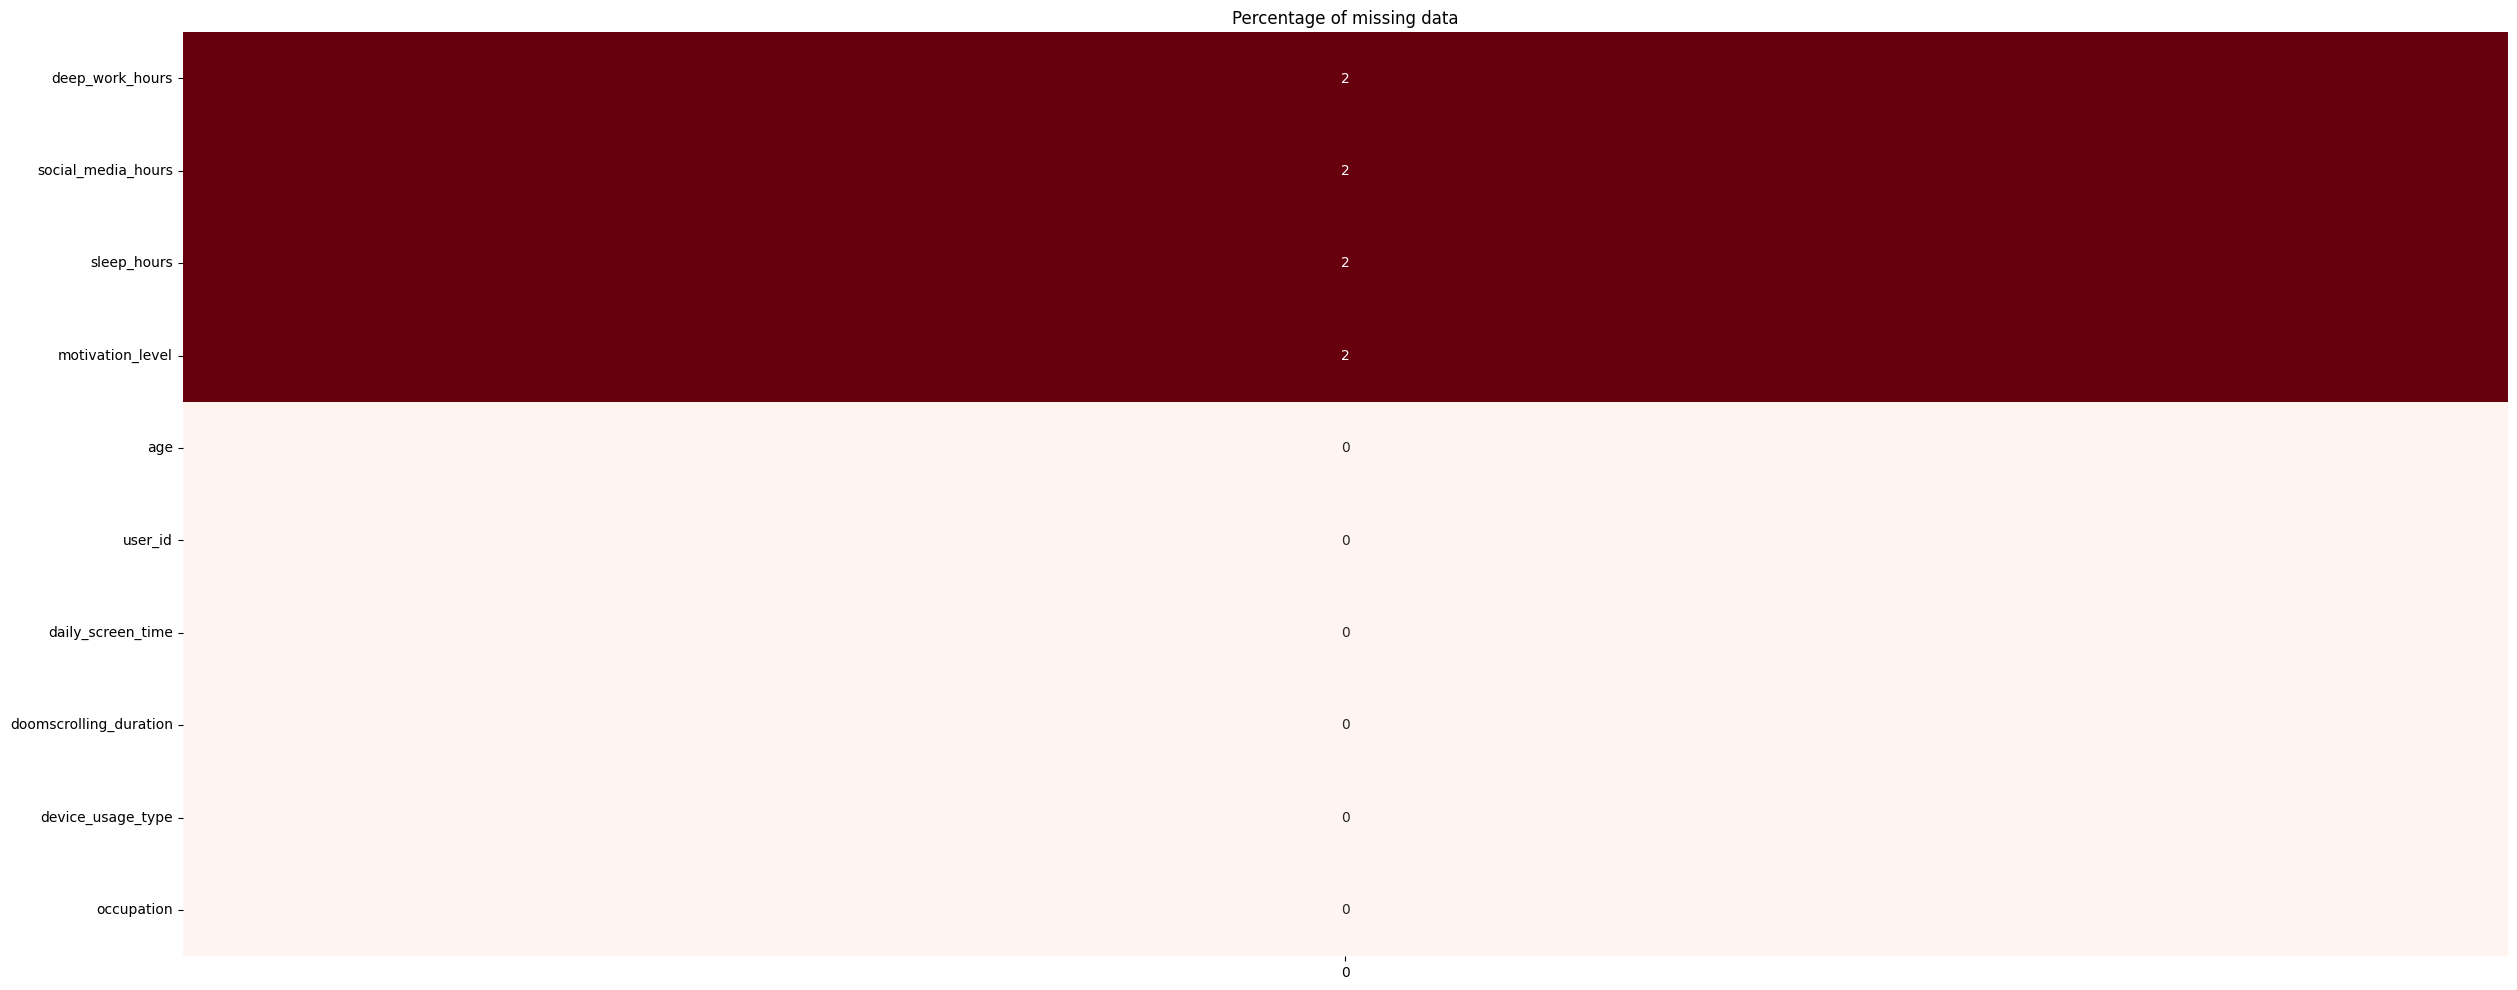

In [9]:
plt.figure(figsize = (30,12))
sns.heatmap(percent_missing.sort_values(ascending=False).to_frame().head(10), annot= True, cmap = "Reds" ,cbar = False)
plt.title("Percentage of missing data")
plt.show()

# **The proportion of missing data is below 3%; therefore, mean imputation will be applied.**

In [10]:
missing_data_columns = list(percent_missing[percent_missing>0].index)
missing_data_columns

['social_media_hours', 'deep_work_hours', 'sleep_hours', 'motivation_level']

In [11]:
for col in missing_data_columns:
  df[col].fillna(df[col].mean(), inplace = True)

In [12]:
df.isnull().sum()

,0
user_id,0
age,0
occupation,0
work_mode,0
device_usage_type,0
daily_screen_time,0
social_media_hours,0
doomscrolling_duration,0
app_switch_frequency,0
notification_count,0


In [13]:
df.duplicated().sum()

np.int64(0)

# **There are no duplicated data**

In [14]:
numerical_features = [ feature for feature in df.columns if df[feature].dtype != "object"]
print(f' We have {len(numerical_features)} numerical features and these are the list: \n{numerical_features}')

 We have 29 numerical features and these are the list: 
['user_id', 'age', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction', 'burnout_risk', 'productivity_score']


In [15]:
categorical_features = [ feature for feature in df.columns if df[feature].dtype == "object"]
categorical_features
print(f' We have {len(categorical_features)} categorical features and these are the list: \n{categorical_features}')

 We have 5 categorical features and these are the list: 
['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']


In [16]:
cat_data ={}
cat_data_list ={}

for col in categorical_features:
  cat_data[col] = len(df[col].unique())
  cat_data_list[col] = df[col].unique()

In [17]:
print(f"The following categorical columns contain these number of unique values:\n{cat_data}")
print(f"The following categorical columns contain these unique values:\n{cat_data_list}\n")

The following categorical columns contain these number of unique values:
{'occupation': 7, 'work_mode': 3, 'device_usage_type': 3, 'mental_state': 4, 'productivity_category': 3}
The following categorical columns contain these unique values:
{'occupation': array(['Content Creator', 'Student', 'Software Engineer', 'Designer',
       'Analyst', 'Freelancer', 'Manager'], dtype=object), 'work_mode': array(['Office', 'Hybrid', 'Remote'], dtype=object), 'device_usage_type': array(['Entertainment-Centric', 'Work-Centric', 'Balanced'], dtype=object), 'mental_state': array(['Balanced', 'Burnout', 'Focused', 'Distracted'], dtype=object), 'productivity_category': array(['High', 'Medium', 'Low'], dtype=object)}



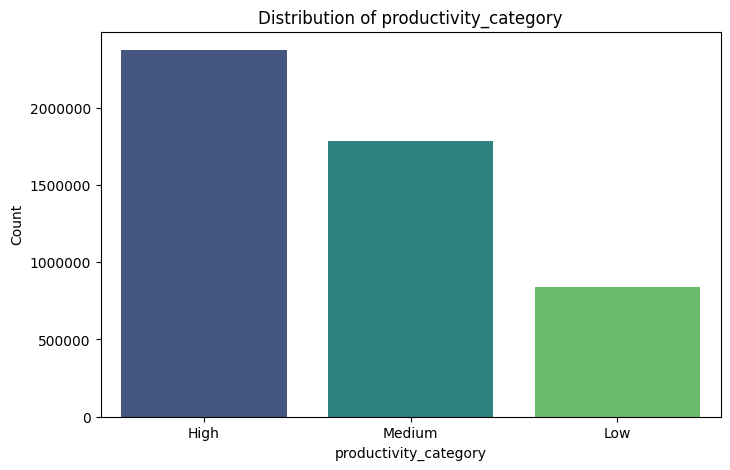

In [18]:
# Plot target distribution
plt.figure(figsize=(8,5))
sns.countplot(x='productivity_category', data=df, palette='viridis')
plt.title('Distribution of productivity_category')
plt.xlabel('productivity_category')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis= 'y')
plt.show()

In [19]:
df['productivity_score'].skew()

np.float64(-0.4543344760748216)

<Axes: >

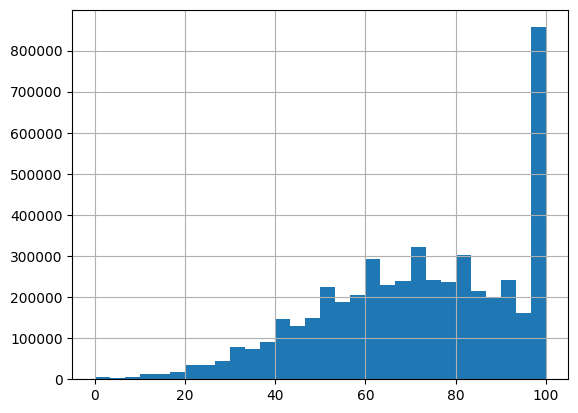

In [20]:
df['productivity_score'].hist(bins = 30)

In [21]:
df.groupby('productivity_category')['productivity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
productivity_category,,,,,,,,
High,2374159.0,90.088842,8.762336,75.0,82.0,91.0,100.0,100.0
Low,841484.0,37.054214,10.208695,0.0,31.0,40.0,45.0,49.0
Medium,1784357.0,62.854054,7.057299,50.0,57.0,63.0,69.0,74.0


# **The target is imbalanced across the three classes, High has the largest number of samples, Medium has a moderate number of samples and Low has the fewest samples**

In [22]:
for col in categorical_features:
  print(f'{df.groupby(col)['productivity_score'].mean().sort_values}')
  print()

<bound method Series.sort_values of occupation
Analyst              71.424493
Content Creator      71.432281
Designer             71.459816
Freelancer           71.464760
Manager              71.429984
Software Engineer    71.439077
Student              71.457359
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of work_mode
Hybrid    71.458965
Office    71.437565
Remote    71.435166
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of device_usage_type
Balanced                 71.429731
Entertainment-Centric    71.453416
Work-Centric             71.450101
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of mental_state
Balanced      71.633843
Burnout       66.518782
Distracted    71.632977
Focused       74.965598
Name: productivity_score, dtype: float64>

<bound method Series.sort_values of productivity_category
High      90.088842
Low       37.054214
Medium    62.854054
Name: productivity_score, dtype: flo

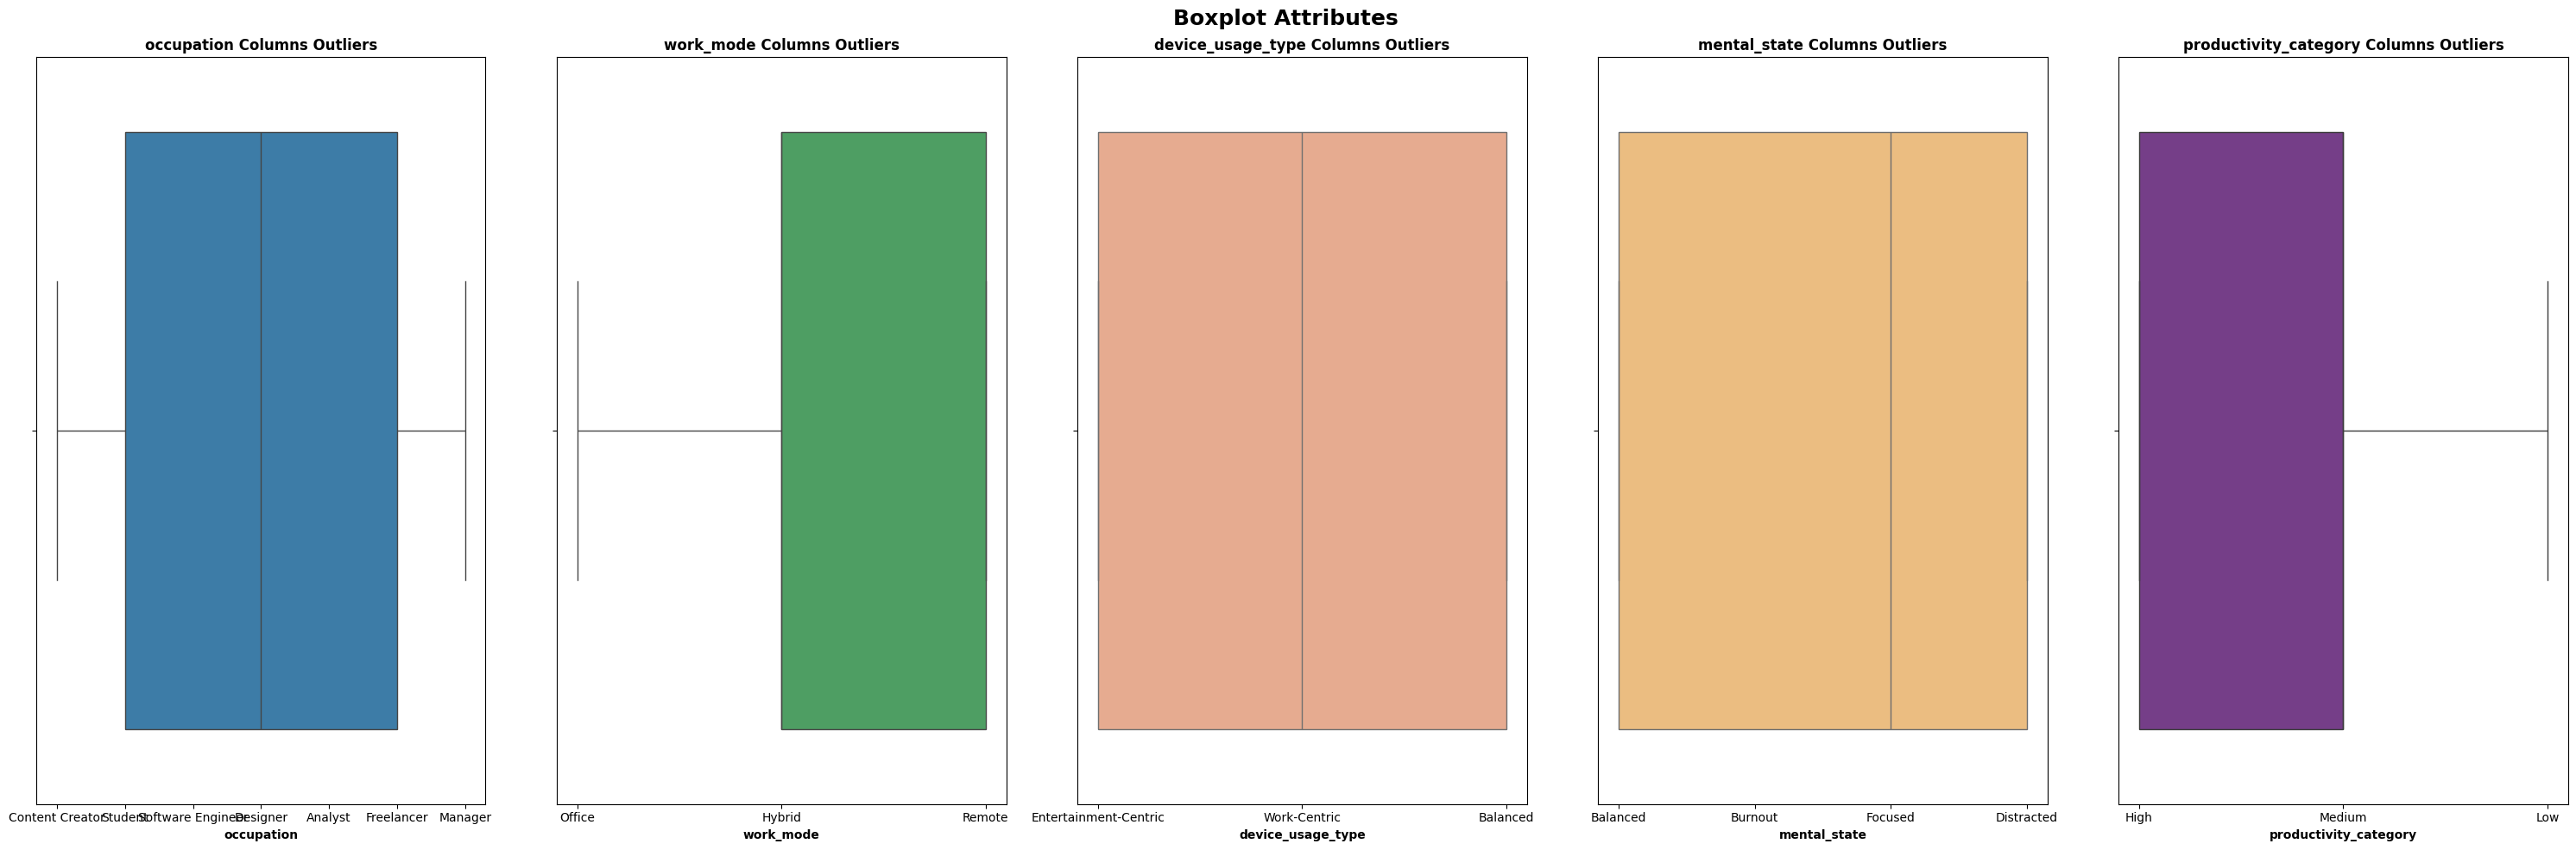

In [23]:
fig, axes = plt.subplots(1,5, figsize = (30,10))
colours = ['#2C7FB8', '#41AB5D', '#F4A582', '#FDBF6F', '#7B3294']
axes = axes.flatten()
# plt.delaxes(axes[-1])
for i in range(len(categorical_features)):
  sns.boxplot(x = df[categorical_features[i]], ax = axes[i], color = colours[i])
  axes[i].set_xlabel(f'{categorical_features[i]}', fontweight= 'bold')
  axes[i].set_title(f'{categorical_features[i]} Columns Outliers', fontweight = 'bold')

plt.suptitle("Boxplot Attributes" , fontweight = 'bold', fontsize = 18)
plt.tight_layout()
plt.show()

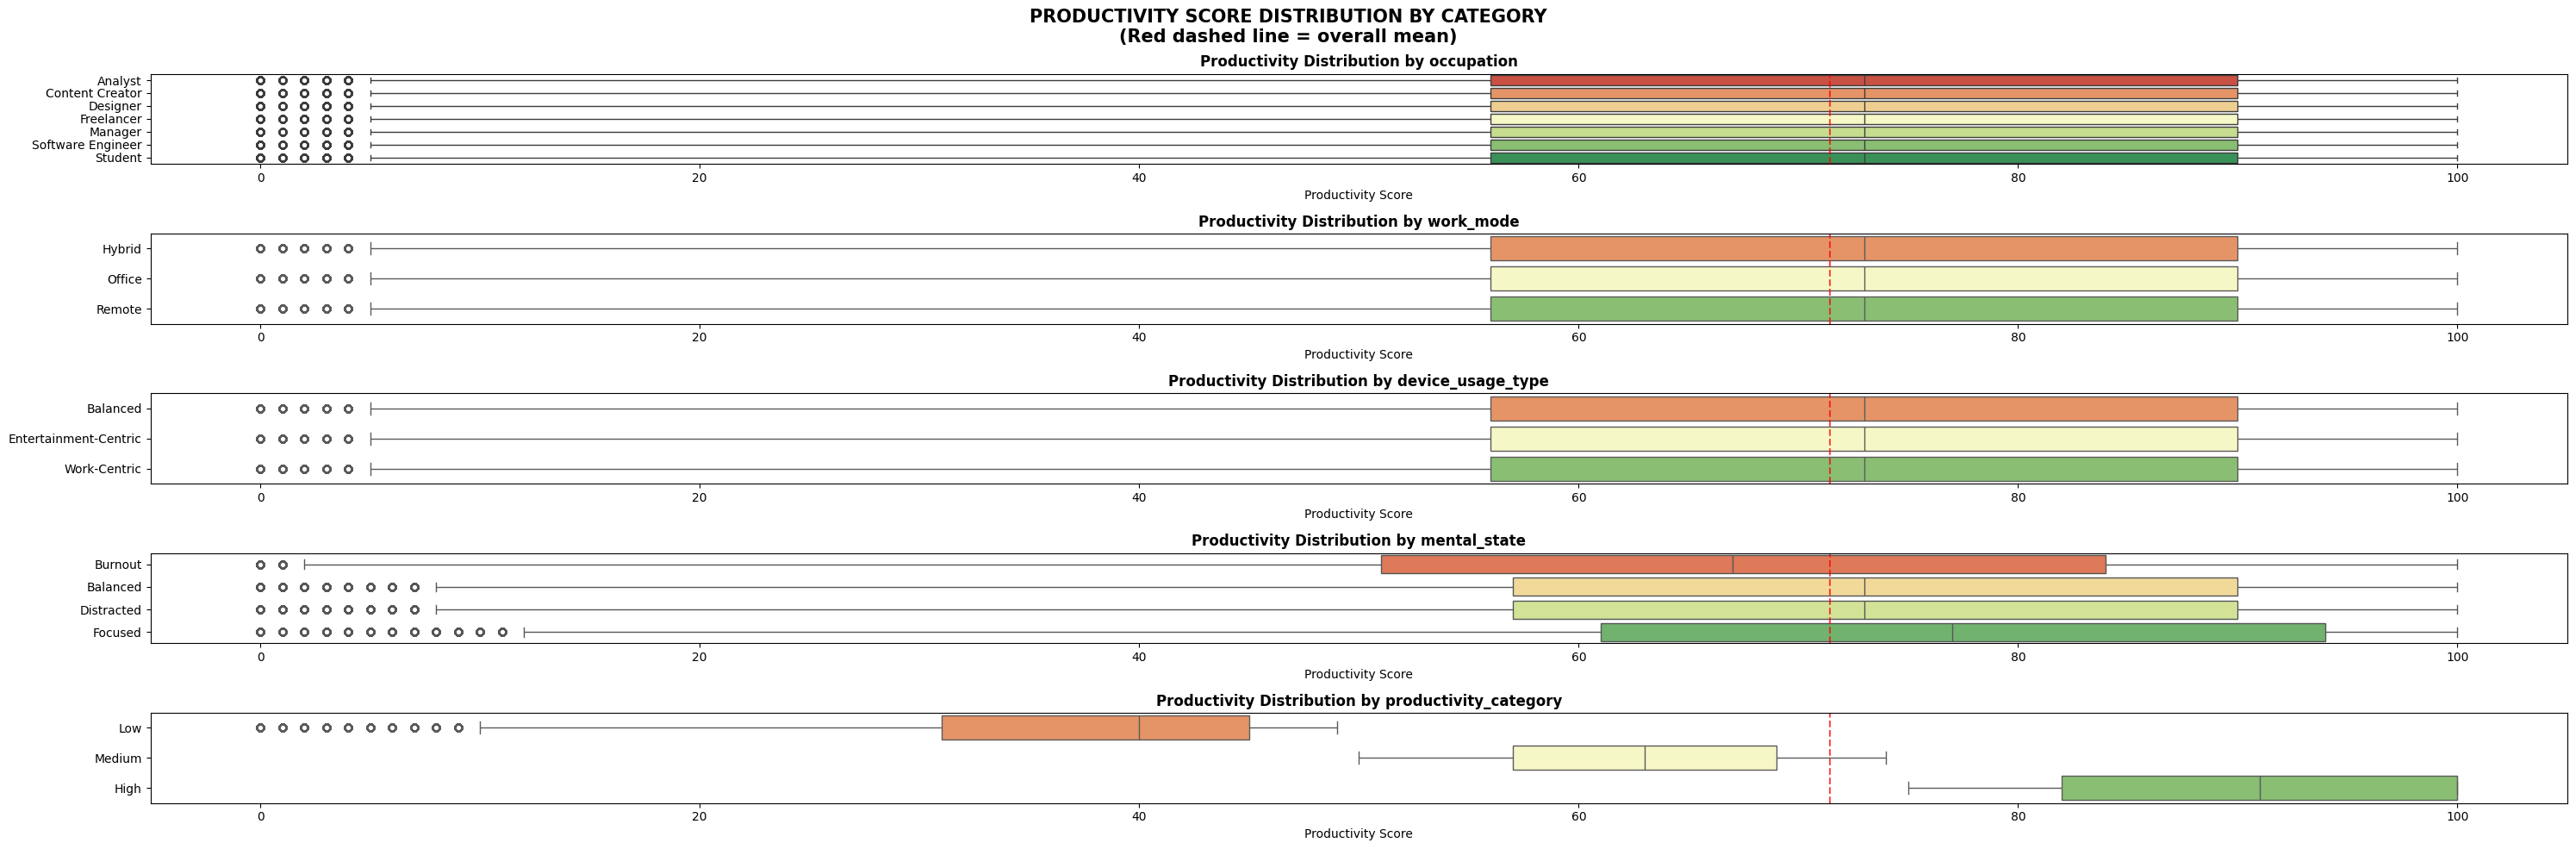

In [24]:

# ============================================================

# PART 3: Box Plots — see the FULL distribution, not just mean

# ============================================================

fig, axes = plt.subplots(5, 1, figsize=(30, 10))

axes = axes.flatten()

for i, col in enumerate(categorical_features):

    # Order categories by median productivity

    order = (df.groupby(col)['productivity_score']

             .median()

             .sort_values()

             .index)

    sns.boxplot(

        data=df,

        x='productivity_score',

        y=col,

        order=order,

        palette='RdYlGn',

        ax=axes[i]

    )

    # Add overall mean line

    axes[i].axvline(df['productivity_score'].mean(),

                    color='red', ls='--', lw=1.5, alpha=0.7)

    axes[i].set_title(f'Productivity Distribution by {col}',

                      fontweight='bold')

    axes[i].set_xlabel('Productivity Score')

    axes[i].set_ylabel('')

plt.suptitle('PRODUCTIVITY SCORE DISTRIBUTION BY CATEGORY\n'

             '(Red dashed line = overall mean)',

             fontsize=15, fontweight='bold')

plt.tight_layout()

plt.show()


# **Productivity scores are predominantly concentrated in the mid-to-high range, with mental state emerging as the most significant differentiator, while occupation and device usage show moderate effects and work mode exhibits minimal impact; the predefined productivity categories are well-separated and consistent with the underlying score distribution.**

# **Feature Group Analysis**

Screen behavior (the “digital habits” cluster):
• daily_screen_time, social_media_hours, doomscrolling_duration, app_switch_frequency, notification_count, smartphone_unlocks, late_night_device_usage

Focus and work quality cluster:
• focus_sessions, deep_work_hours, distraction_frequency, task_completion_rate, concentration_score


Health and wellbeing cluster:
• sleep_hours, sleep_quality, caffeine_intake, physical_activity, stress_level, mental_fatigue, emotional_exhaustion

Work environment cluster:
• workspace_quality, meeting_hours, internet_stability, remote_work_days, work_satisfaction, motivation_level

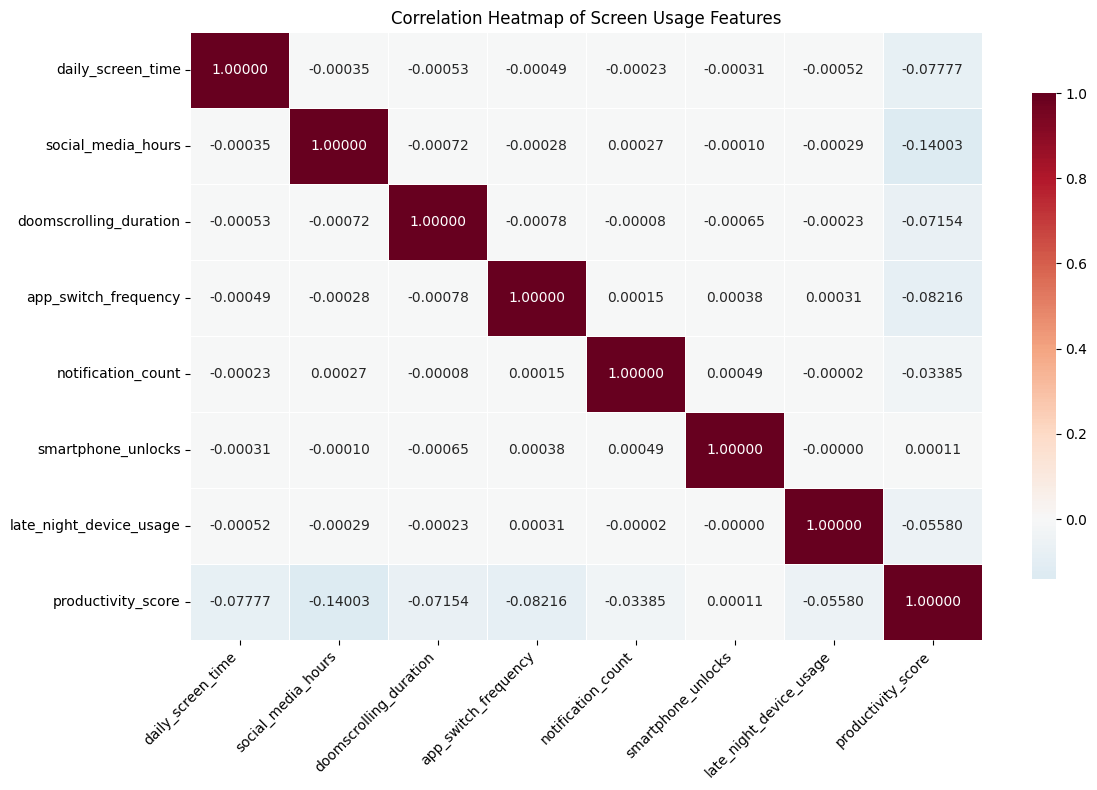

In [30]:
Screen_behavior_cols = ['daily_screen_time', 'social_media_hours',
              'doomscrolling_duration', 'app_switch_frequency',
              'notification_count', 'smartphone_unlocks',
              'late_night_device_usage', 'productivity_score']
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Screen_behavior_cols].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Screen Usage Features", fontsize=12)

plt.tight_layout()
plt.show()


The heatmap shows that screen usage features have extremely weak linear relationships with productivity, indicating that any influence they have is likely nonlinear or minimal.

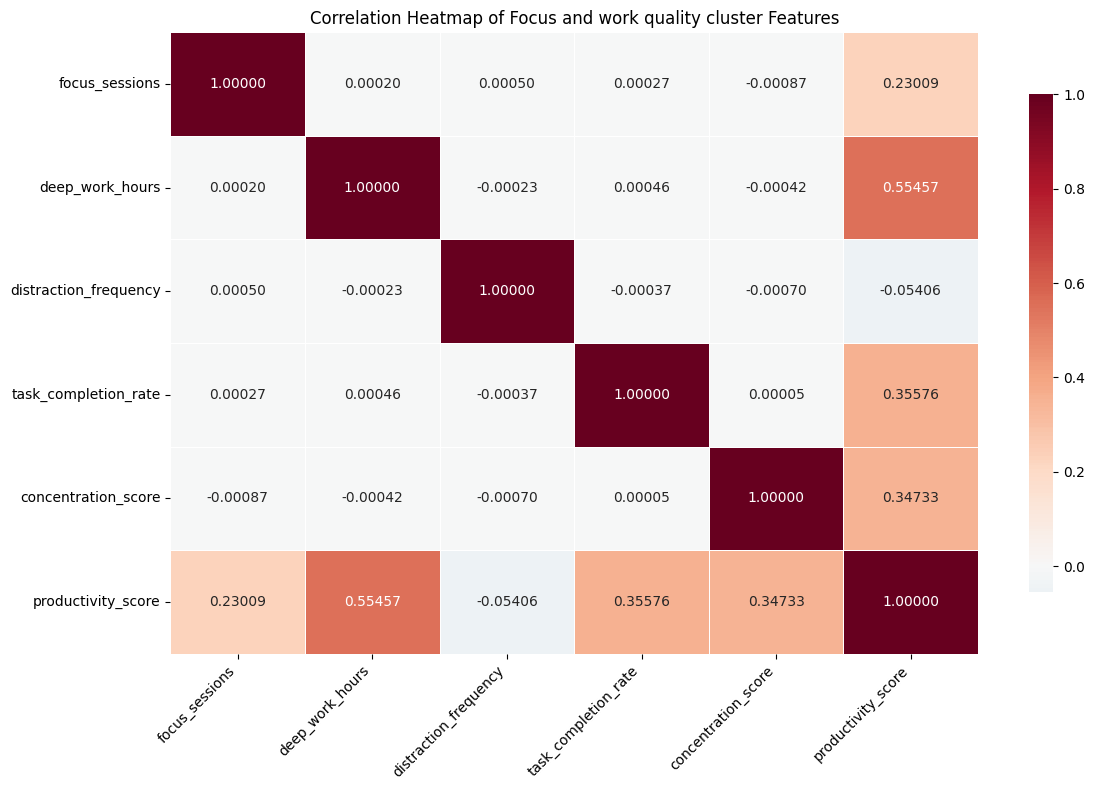

In [33]:
Focus_and_work_quality_cluster = [ "focus_sessions", "deep_work_hours", "distraction_frequency", "task_completion_rate", "concentration_score", 'productivity_score']

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Focus_and_work_quality_cluster].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Focus and work quality cluster Features", fontsize=12)

plt.tight_layout()
plt.show()

**Unlike screen usage features, focus and work-quality variables show strong and meaningful relationships with productivity, with deep work hours emerging as the most important driver.**

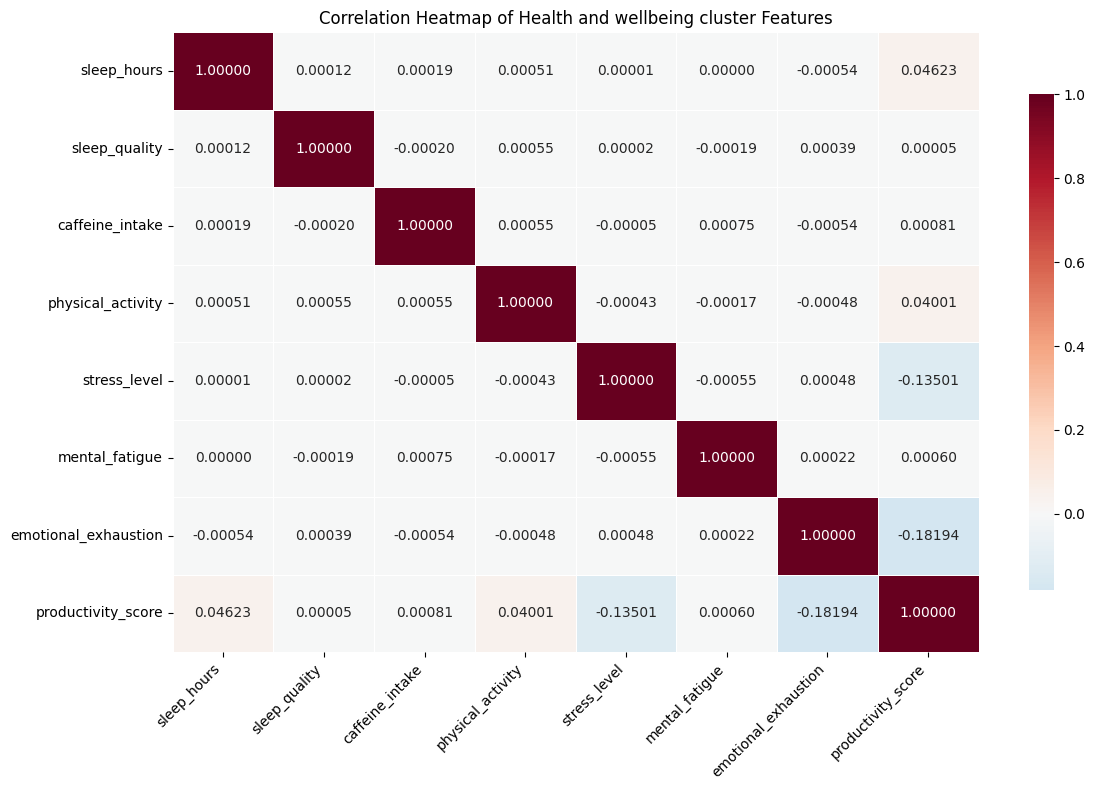

In [34]:
Health_and_wellbeing_cluster = ["sleep_hours", "sleep_quality", "caffeine_intake", "physical_activity", "stress_level", "mental_fatigue", "emotional_exhaustion", "productivity_score" ]
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Health_and_wellbeing_cluster].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Health and wellbeing cluster Features", fontsize=12)

plt.tight_layout()
plt.show()

**Productivity is not strongly driven by lifestyle metrics directly, but by the ability to focus and work deeply, which is influenced (to some extent) by stress and emotional exhaustion.**

**Health and wellbeing variables show weak direct correlations with productivity, with emotional exhaustion and stress level being the only meaningful negative drivers, while most other factors (sleep, caffeine, activity) exhibit minimal direct influence.**

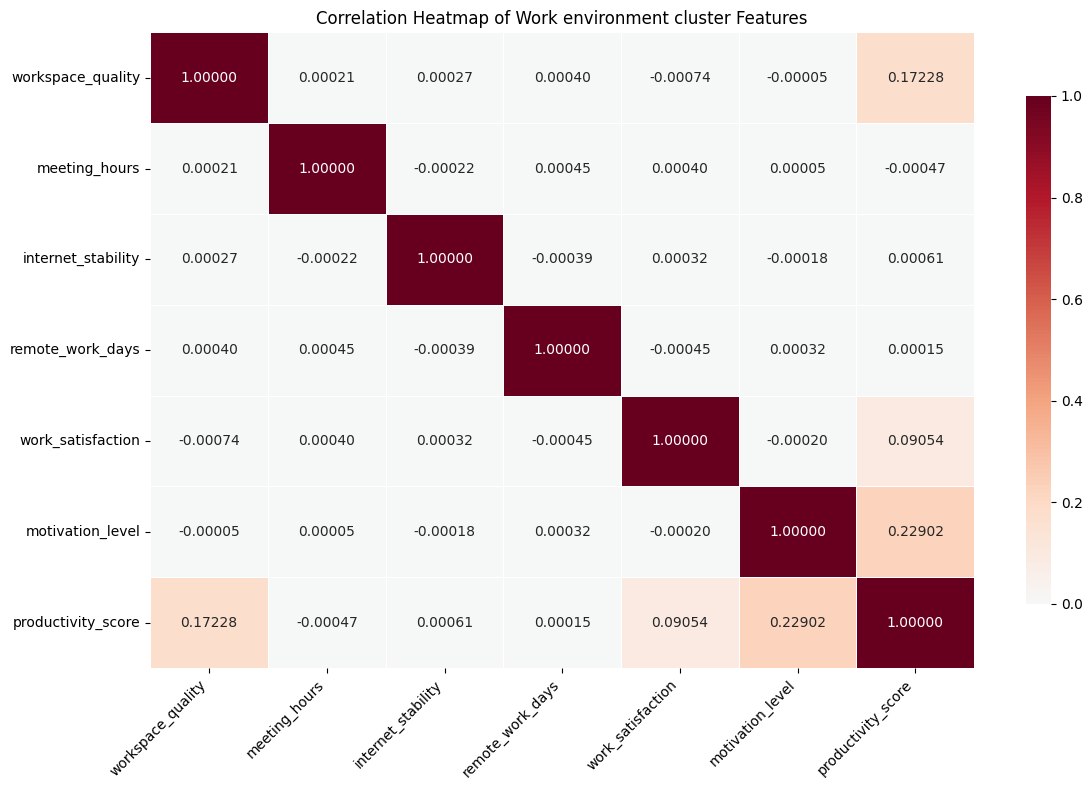

In [37]:
Work_environment_cluster = ["workspace_quality", "meeting_hours", "internet_stability", "remote_work_days", "work_satisfaction", "motivation_level", "productivity_score"]
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[Work_environment_cluster].corr(),
    annot=True,
    fmt='.5f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Work environment cluster Features", fontsize=12)

plt.tight_layout()
plt.show()

**Productivity depends more on internal mindset and working style than external environment.**

**Work environment has some influence on productivity (mainly through motivation and workspace quality), but its impact is significantly weaker than focus and deep work behaviours.**

**Among work environment features, motivation level and workspace quality show moderate influence on productivity, while factors like meetings, internet stability, and remote work have negligible impact.**

